### Load libraries

In [1]:
from pybaseball import statcast
import os
import pickle
from datetime import date

import pandas as pd
import numpy as np
import polars as pl

import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

import requests

import matplotlib.pyplot as plt
%matplotlib inline

from huggingface_hub import HfApi

In [2]:
# Download Statcast cache from HuggingFace if not present locally
CACHE_PATH = "statcast_raw_cache.parquet"
_CACHE_HF_URL = (
    "https://huggingface.co/datasets/perld/stuff-plus-data"
    "/resolve/main/statcast_raw_cache.parquet"
)

if not os.path.exists(CACHE_PATH):
    print("Cache not found locally. Attempting download from HuggingFace...")
    try:
        _resp = requests.get(_CACHE_HF_URL, timeout=300)
        _resp.raise_for_status()
        with open(CACHE_PATH, "wb") as _f:
            _f.write(_resp.content)
        print(f"Cache downloaded ({len(_resp.content)/1e6:.1f} MB).")
    except Exception as _e:
        print(f"Download failed: {_e}. Will run full historical pull.")
else:
    print(f"Cache found at {CACHE_PATH}.")


Cache found at statcast_raw_cache.parquet.


In [3]:
def load_or_update_statcast(cache_path, full_start="2021-03-01"):
    today = date.today().isoformat()

    if os.path.exists(cache_path):
        print(f"Cache found at {cache_path}. Loading...")
        cached = pd.read_parquet(cache_path)
        max_date = pd.to_datetime(cached["game_date"]).max()
        pull_start = (max_date + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

        if pull_start > today:
            print("Cache is up to date. No new data to pull.")
            return cached

        print(f"Pulling new Statcast data from {pull_start} through {today}...")
        new_data = statcast(pull_start, today)

        if new_data is not None and len(new_data) > 0:
            print(f"Appending {len(new_data):,} new rows to cache.")
            combined = pd.concat([cached, new_data], ignore_index=True)
            combined.to_parquet(cache_path, index=False)
            print(f"Cache updated and saved to {cache_path}.")
            return combined
        else:
            print("No new data returned. Returning cached data.")
            return cached

    else:
        print(f"No cache found. Running full pull from {full_start} through {today}...")
        raw = statcast(full_start, today)
        print(f"Pull complete. {len(raw):,} rows retrieved.")
        raw.to_parquet(cache_path, index=False)
        print(f"Cache saved to {cache_path}.")
        return raw


FULL_START = "2021-03-01"
raw_data = load_or_update_statcast(CACHE_PATH, full_start=FULL_START)
min_year = pd.to_datetime(FULL_START).year
raw_data = raw_data[raw_data["game_year"] >= min_year].copy()
print(f"Filtered to {min_year}+. Remaining years: {sorted(raw_data['game_year'].dropna().astype(int).unique().tolist())}")
print(raw_data.shape)


Cache found at statcast_raw_cache.parquet. Loading...
Pulling new Statcast data from 2026-04-05 through 2026-04-05...
This is a large query, it may take a moment to complete


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.31it/s]


No new data returned. Returning cached data.
Filtered to 2021+. Remaining years: [2021, 2022, 2023, 2024, 2025, 2026]
(3920886, 118)


In [4]:
df = raw_data.copy().reset_index(drop=True)
# re-format names to readable format
split_names = df["player_name"].fillna("").str.split(",", n=1)
df["PlayerName"] = np.where(
    split_names.str.len() == 2,
    split_names.str[1].str.strip() + " " + split_names.str[0].str.strip(),
    df["player_name"]
)

In [5]:
## Define a dictionary to group outcomes together for expected run values
des_dict = {'ball':'ball',
'hit_into_play':'hit_into_play',
'called_strike':'called_strike',
'foul':'foul',
'swinging_strike':'swinging_strike',
'blocked_ball':'ball',
'swinging_strike_blocked':'swinging_strike',
'foul_tip':'swinging_strike',
'foul_bunt':'foul',
'hit_by_pitch':'hit_by_pitch',
'pitchout':'ball',
'missed_bunt':'swinging_strike',
'bunt_foul_tip':'swinging_strike',
'foul_pitchout':'foul',}

## Define a dictionary to group events together for expected run values
ev_dict = {'game_advisory':np.nan,
 'single':'single',
 'walk':'walk',
 np.nan:np.nan,
 'strikeout':'strikeout',
 'field_out':'field_out',
 'force_out':'field_out',
 'double':'double',
 'hit_by_pitch':'hit_by_pitch',
 'home_run':'home_run',
 'grounded_into_double_play':'field_out',
 'fielders_choice_out':'field_out',
 'fielders_choice':'field_out',
 'field_error':np.nan,
 'double_play':'field_out',
 'sac_fly':'field_out',
 'strikeout_double_play':np.nan,
 'triple':'triple',
 'caught_stealing_2b':np.nan,
 'sac_bunt':'field_out',
 'catcher_interf':np.nan,
 'caught_stealing_3b':np.nan,
 'sac_fly_double_play':'field_out',
 'triple_play':'field_out',
 'other_out':'field_out',
 'pickoff_3b':np.nan,
 'caught_stealing_home':np.nan,
 'pickoff_1b':np.nan,
 'pickoff_2b':np.nan,
 'wild_pitch':'wild_pitch',
 'stolen_base_2b':np.nan,
 'pickoff_caught_stealing_3b':np.nan,
 'pickoff_caught_stealing_2b':np.nan,
 'sac_bunt_double_play':np.nan,
 'passed_ball':np.nan,
 'pickoff_caught_stealing_home':np.nan,}

In [6]:
# Define a function which applies relevant transformations
# Code derived from Thomas Nestico

def clean_for_xrv(df, val_year):
    df = df[(df.balls != 4) & (df.strikes != 3)].copy()

    df["des_new"] = df["description"].map(des_dict)
    df["des_new"] = np.where((df["des_new"] == "ball") & (df["balls"] == 3), "walk", df["des_new"])
    df["des_new"] = np.where(
        (df["des_new"].isin(["called_strike", "swinging_strike"])) & (df["strikes"] == 2),
        "strikeout",
        df["des_new"],
    )
    df["ev_new"] = df.loc[df["des_new"] == "hit_into_play", "events"].map(ev_dict)
    df.loc[df["des_new"] == "hit_into_play", "des_new"] = df.loc[df["des_new"] == "hit_into_play", "ev_new"]
    df = df.dropna(subset=["des_new"])

    train_mask = (df["game_year"].to_numpy() < val_year)

    des_values = (
        df.loc[train_mask]
          .groupby(["des_new", "strikes", "balls"])["delta_run_exp"]
          .mean()
          .reset_index(name="delta_run_exp_mean")
    )

    df = df.merge(des_values, on=["des_new", "strikes", "balls"], how="left")

    global_mean = df.loc[train_mask, "delta_run_exp"].mean()
    df["delta_run_exp_mean"] = df["delta_run_exp_mean"].fillna(global_mean)

    return df.dropna(subset=["pitch_type"])

In [7]:
def add_primary_pitch_deltas(
    df,
    primary_choices=("FF", "SI", "FC"),
    *,
    pitcher_col="pitcher",
    year_col="game_year",
    pitch_type_col="pitch_type",
    speed_col="release_speed",
    pfx_x_col="pfx_x",
    pfx_z_col="pfx_z",
):
    """
    Adds primary pitch baseline per pitcher-season and deltas vs that baseline.

    Primary pitch definition:
      - among `primary_choices`, pick the most-used pitch type for a given pitcher-season
      - tiebreaker: higher avg speed

    Fallback if pitcher-season throws none of `primary_choices`:
      - use fastest pitch (by avg speed) for that pitcher-season

    Returns a pandas DataFrame with:
      - avg_primary_speed, avg_primary_pfx_x, avg_primary_pfx_z
      - primary_delta_release_speed, primary_delta_pfx_x, primary_delta_pfx_z
    """

    pdf = df.copy()
    pl_df = pl.from_pandas(pdf)

    group_keys = [pitcher_col, year_col, pitch_type_col]

    # aggregate pitch-type means and counts per pitcher-season
    agg = (
        pl_df.group_by(group_keys)
        .agg(
            pl.len().alias("pt_count"),
            pl.col(speed_col).mean().alias("pt_avg_speed"),
            pl.col(pfx_z_col).mean().alias("pt_avg_pfx_z"),
            pl.col(pfx_x_col).mean().alias("pt_avg_pfx_x"),
        )
    )

    # candidate primary among chosen pitch types
    primary_candidates = (
        agg.filter(pl.col(pitch_type_col).is_in(list(primary_choices)))
        .sort(
            by=[pitcher_col, year_col, "pt_count", "pt_avg_speed"],
            descending=[False, False, True, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("avg_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("avg_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("avg_primary_pfx_x"),
        )
    )

    # fallback: fastest pitch type for that pitcher-season (if no primary_choices)
    fastest_fallback = (
        agg.sort(
            by=[pitcher_col, year_col, "pt_avg_speed"],
            descending=[False, False, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("fb_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("fb_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("fb_primary_pfx_x"),
        )
    )

    # join both baselines to every pitch row
    pl_df = (
        pl_df.join(primary_candidates, on=[pitcher_col, year_col], how="left")
             .join(fastest_fallback, on=[pitcher_col, year_col], how="left")
             .with_columns(
                 pl.when(pl.col("avg_primary_speed").is_null())
                   .then(pl.col("fb_primary_speed"))
                   .otherwise(pl.col("avg_primary_speed"))
                   .alias("avg_primary_speed"),
                 pl.when(pl.col("avg_primary_pfx_z").is_null())
                   .then(pl.col("fb_primary_pfx_z"))
                   .otherwise(pl.col("avg_primary_pfx_z"))
                   .alias("avg_primary_pfx_z"),
                 pl.when(pl.col("avg_primary_pfx_x").is_null())
                   .then(pl.col("fb_primary_pfx_x"))
                   .otherwise(pl.col("avg_primary_pfx_x"))
                   .alias("avg_primary_pfx_x"),
             )
             .drop(["fb_primary_speed", "fb_primary_pfx_z", "fb_primary_pfx_x"])
    )

    # deltas vs baseline
    pl_df = pl_df.with_columns(
        (pl.col(speed_col) - pl.col("avg_primary_speed")).alias("primary_delta_release_speed"),
        (pl.col(pfx_z_col) - pl.col("avg_primary_pfx_z")).alias("primary_delta_pfx_z"),
        (pl.col(pfx_x_col) - pl.col("avg_primary_pfx_x")).alias("primary_delta_pfx_x"),
    )

    pl_df = pl_df.with_columns(pl.col(year_col).cast(pl.Int64))

    return pl_df.to_pandas()

In [8]:
def clean_data(df, val_year):
    
    df = df[df.game_type == 'R'].copy()  # regular season only

    # required columns
    must_have_cols = [
        'p_throws', 'pfx_x', 'pfx_z', 'release_speed', 'spin_axis',
        'release_spin_rate', 'release_extension',
        'release_pos_x', 'release_pos_z', 'arm_angle', 'p_throws'
    ]
    df = df.dropna(subset=must_have_cols)

    # remove unidentified pitches
    df = df[df.pitch_name != 'Other']

    # remove bunts
    bunt_plays = ['bunt_foul_tip', 'foul_bunt', 'missed_bunt']
    df = df[~df.description.isin(bunt_plays)]

    # remove clearly bad extensions
    df = df[df.release_extension <= 10]

    # rename batter stance
    df = df.rename(columns={'stand': 'batter_handedness'})

    # drop deprecated columns
    deprecated_columns = [c for c in df.columns if 'deprecated' in c]
    df = df.drop(columns=deprecated_columns)

    # filter rare pitch types globally
    vc = df['pitch_type'].value_counts()
    included_pitches = vc[vc >= 5000].index
    df = df[df.pitch_type.isin(included_pitches)]

    # handedness feature
    df['is_lefty'] = (df['p_throws'] == 'L').astype(int)

    # convert movement to inches
    df['pfx_x'] = df['pfx_x'] * 12.0
    df['pfx_z'] = df['pfx_z'] * 12.0
    
    # same_side matchup feature — captures platoon split context
    df['same_side'] = (df['p_throws'] == df['batter_handedness']).astype(int)

    # mirror pfx_x for model so arm-side is always positive regardless of handedness
    df['pfx_x_mirrored'] = df['pfx_x'] * np.where(df['p_throws'] == 'L', -1, 1)

    eps = 1e-9
    train_mask = df['game_year'] < val_year  # avoid leakage

    # -------------------------
    # spin efficiency
    # accounts for flight distance via extension; transverse spin back-calculated from observed movement
    # -------------------------
    SEAM_CONSTANT = 0.01267

    df['total_movement'] = np.sqrt(df['pfx_x']**2 + df['pfx_z']**2)
    df['flight_distance'] = 60.5 - df['release_extension']

    df['transverse_spin_est'] = (
        df['total_movement'] * df['release_speed']
        / (SEAM_CONSTANT * df['flight_distance'] + eps)
    )

    df['spin_efficiency'] = (
        df['transverse_spin_est'] / (df['release_spin_rate'] + eps)
    ).clip(0, 1)

    # -------------------------
    # spin axis features
    # -------------------------
    df['spin_axis'] = pd.to_numeric(df['spin_axis'], errors='coerce')
    df = df.dropna(subset=['spin_axis'])

    df['spin_axis_rad'] = np.deg2rad(df['spin_axis'])
    df['spin_axis_x'] = np.cos(df['spin_axis_rad'])
    df['spin_axis_y'] = np.sin(df['spin_axis_rad'])

    # -------------------------
    # seam-shifted wake features
    # Magnus magnitude = spin_efficiency fraction of observed movement
    # direction derived from spin axis
    # SSW = residual after removing Magnus estimate
    # convention: HB_obs > 0 -> 3B side, HB_obs < 0 -> 1B side
    # -------------------------
    df['HB_obs']  = -df['pfx_x']
    df['iVB_obs'] =  df['pfx_z']

    df['movement_mag_obs'] = np.sqrt(
        df['HB_obs']**2 + df['iVB_obs']**2
    )

    # Magnus magnitude = spin efficiency fraction of total movement
    df['magnus_mag_est'] = df['spin_efficiency'] * df['movement_mag_obs']

    # Magnus direction from spin axis
    theta = np.deg2rad(df['spin_axis'] - 90)
    df['HB_magnus_est']  = -df['magnus_mag_est'] * np.cos(theta)
    df['iVB_magnus_est'] =  df['magnus_mag_est'] * np.sin(theta)

    # SSW = residual after removing Magnus
    df['ssw_x'] = df['HB_obs'] - df['HB_magnus_est']
    df['ssw_z'] = df['iVB_obs'] - df['iVB_magnus_est']
    df['ssw_in'] = np.sqrt(df['ssw_x']**2 + df['ssw_z']**2)

    # Pitch usage filtering
    counts = df.groupby(['pitcher', 'game_year', 'pitch_type']).size().rename('count')
    totals = df.groupby(['pitcher', 'game_year']).size().rename('total')

    pitch_frequencies = (
        counts.to_frame()
              .join(totals, on=['pitcher', 'game_year'])
    )
    pitch_frequencies['usage'] = pitch_frequencies['count'] / pitch_frequencies['total']
    pitch_frequencies = pitch_frequencies.reset_index()

    pitch_frequencies = pitch_frequencies[
        (pitch_frequencies['count'] >= 10) &
        (pitch_frequencies['usage'] > 0.01)
    ]

    df = df.merge(
        pitch_frequencies[['pitcher', 'game_year', 'pitch_type']],
        on=['pitcher', 'game_year', 'pitch_type'],
        how='inner'
    )

    return df, pitch_frequencies

In [9]:
year_col = "game_year"
pitch_type_col = "pitch_type"
target = "delta_run_exp_mean"

all_years = sorted(df[year_col].dropna().astype(int).unique())
if len(all_years) < 3:
    raise ValueError(f"Need >=3 distinct years for train/tune/report. Found: {all_years}")

report_year = int(all_years[-1])
val_year    = int(all_years[-2])          # tune / early-stop year
train_years = [int(y) for y in all_years[:-2]]

print(f"Train years: {train_years}")
print(f"Tune year:   {val_year}")
print(f"Report year: {report_year}")

Train years: [2021, 2022, 2023, 2024]
Tune year:   2025
Report year: 2026


In [10]:
FORCE_RETRAIN = False

scored_filename = f"df_scored_{report_year}.parquet"
model_filename  = f"model_{report_year}.pkl"

# Attempt to download existing scored file from HuggingFace
_scored_url = (
    f"https://huggingface.co/datasets/perld/stuff-plus-data"
    f"/resolve/main/{scored_filename}"
)
if not os.path.exists(scored_filename):
    try:
        _r = requests.get(_scored_url, timeout=300)
        _r.raise_for_status()
        with open(scored_filename, "wb") as _f:
            _f.write(_r.content)
        print(f"Downloaded {scored_filename} from HuggingFace.")
    except Exception as _e:
        print(f"Could not download {scored_filename}: {_e}")

last_cached_rows = len(df[df["game_year"] == report_year])

if not os.path.exists(scored_filename):
    last_scored_rows = 0
else:
    last_scored_rows = len(pd.read_parquet(scored_filename))

RETRAIN = FORCE_RETRAIN or (last_cached_rows > last_scored_rows)

print(
    f"RETRAIN={RETRAIN} | scored_rows={last_scored_rows} | "
    f"cached_rows={last_cached_rows}"
)


RETRAIN=True | scored_rows=23253 | cached_rows=74742


In [11]:
df = clean_for_xrv(df, val_year)

In [12]:
# Clean + engineer features
primary_choices = ['FF', 'SI', 'FC']
df, pitch_frequencies = clean_data(df, val_year)
df = add_primary_pitch_deltas(df, primary_choices=primary_choices)

In [13]:
ID_COLS = ["pitcher", "PlayerName"]

numeric_features = [
    'pfx_x_mirrored',
    'pfx_z',
    'release_speed', 'release_spin_rate', 'release_extension',
    'release_pos_x', 'release_pos_z',
    'spin_axis_x', 'spin_axis_y', 'spin_efficiency',
    'ssw_x', 'ssw_z', 'ssw_in',
    'same_side',
    'primary_delta_release_speed',
    'primary_delta_pfx_x', 'primary_delta_pfx_z',
]

categorical_features = [pitch_type_col]

model_features = numeric_features + categorical_features

KEEP_COLS = (
    ID_COLS
    + [year_col, target]
    + model_features
    + [
        "pfx_x",
        "spin_axis",
        "pitch_name",
        "p_throws",
        "batter_handedness",
        "arm_angle",
        "HB_obs",
        "iVB_obs",
        "movement_mag_obs",
        "magnus_mag_est",
        "HB_magnus_est",
        "iVB_magnus_est",
    ]
)

KEEP_COLS = list(dict.fromkeys(KEEP_COLS))

df_current = df[KEEP_COLS].copy()

In [14]:
def tune_refit_predict(
    df_all,
    tune_year,
    report_year,
    train_years,
    *,
    year_col="game_year",
    pitch_type_col="pitch_type",
    target_col=target,
    model_features=model_features,
    n_trials=50,
):

    n_estimators_max = 5000
    early_stopping_rounds = 100
    seed = 162

    # 1) Tune on tune_year
    df_train = df_all[df_all[year_col].isin(train_years)].copy()
    df_tune  = df_all[df_all[year_col] == tune_year].copy()

    X_train = df_train[model_features].copy()
    y_train = df_train[target_col].copy()
    X_tune  = df_tune[model_features].copy()
    y_tune  = df_tune[target_col].copy()

    X_train[pitch_type_col] = X_train[pitch_type_col].astype("category")
    X_tune[pitch_type_col]  = X_tune[pitch_type_col].astype("category")

    def objective(trial):
        params = {
            "random_state": seed,
            "metric": "rmse",
            "n_estimators": n_estimators_max,
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.10, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 25.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 25.0, log=True),
            "force_row_wise": True,
            "verbosity": -1,
        }

        model = LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_tune, y_tune)],
            eval_metric="rmse",
            categorical_feature=[pitch_type_col],
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )
        preds = model.predict(X_tune)
        return mean_squared_error(y_tune, preds, squared=False)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # capture best params
    best_params = study.best_params.copy()
    best_params.update({
        "random_state": seed,
        "metric": "rmse",
        "force_row_wise": True,
        "verbosity": -1,
    })

    # fit a probe model once more to get best_iteration_
    probe_params = best_params.copy()
    probe_params["n_estimators"] = n_estimators_max

    probe_model = LGBMRegressor(**probe_params)
    probe_model.fit(
        X_train, y_train,
        eval_set=[(X_tune, y_tune)],
        eval_metric="rmse",
        categorical_feature=[pitch_type_col],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
    )

    best_n_estimators = int(getattr(probe_model, "best_iteration_", None) or n_estimators_max)
    best_params["n_estimators"] = best_n_estimators

    tune_preds = probe_model.predict(X_tune)
    tune_rmse = mean_squared_error(y_tune, tune_preds, squared=False)

    # 2) Refit on (train_years + tune_year), params fixed
    refit_years = list(train_years) + [tune_year]
    df_refit = df_all[df_all[year_col].isin(refit_years)].copy()

    X_refit = df_refit[model_features].copy()
    y_refit = df_refit[target_col].copy()

    X_refit[pitch_type_col] = X_refit[pitch_type_col].astype("category")

    final_model = LGBMRegressor(**best_params)
    final_model.fit(
        X_refit, y_refit,
        categorical_feature=[pitch_type_col],
    )

    # 3) Predict/report on report_year
    df_report = df_all[df_all[year_col] == report_year].copy()
    X_report  = df_report[model_features].copy()
    X_report[pitch_type_col] = X_report[pitch_type_col].astype("category")

    df_report["pred_target_oos"] = final_model.predict(X_report)

    report_rmse = None
    if target_col in df_report.columns and df_report[target_col].notna().any():
        report_rmse = mean_squared_error(
            df_report[target_col],
            df_report["pred_target_oos"],
            squared=False,
        )

    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    result = {
        "report_year": report_year,
        "tune_year": tune_year,
        "train_years": train_years,
        "refit_years": refit_years,

        "study": study,
        "best_params": best_params.copy(),
        "best_n_estimators": best_n_estimators,

        "probe_model": probe_model,
        "final_model": final_model,

        "df_train": df_train,
        "df_tune": df_tune,
        "df_refit": df_refit,
        "df_report": df_report,

        "X_train": X_train,
        "y_train": y_train,
        "X_tune": X_tune,
        "y_tune": y_tune,
        "X_refit": X_refit,
        "y_refit": y_refit,
        "X_report": X_report,

        "tune_preds": tune_preds,
        "tune_rmse": tune_rmse,
        "report_rmse": report_rmse,

        "feature_importance": feature_importance,
    }

    return result

In [15]:
def rolling_oos_predictions(
    df_all,
    *,
    year_col="game_year",
    min_train_years=2,
    n_trials=50,
    force_retrain=False,
):
    years = sorted(df_all[year_col].dropna().astype(int).unique())

    all_preds = []
    results_by_year = {}
    models_by_year = {}
    summaries = []

    # Need at least [train years] + [tune year] + [report year]
    for i in range(min_train_years + 1, len(years)):
        report_year = int(years[i])
        tune_year = int(years[i - 1])
        train_years = [int(y) for y in years[:i - 1]]

        print(f"\n=== report_year={report_year} | tune_year={tune_year} | train_years={train_years} ===")

        model_file = f"model_{report_year}.pkl"
        loaded_from_cache = False

        if not force_retrain:
            # Try to load from local file, downloading from HuggingFace if needed
            if not os.path.exists(model_file):
                _model_url = (
                    f"https://huggingface.co/datasets/perld/stuff-plus-data"
                    f"/resolve/main/{model_file}"
                )
                try:
                    _r = requests.get(_model_url, timeout=300)
                    _r.raise_for_status()
                    with open(model_file, "wb") as _f:
                        _f.write(_r.content)
                    print(f"Downloaded {model_file} from HuggingFace.")
                except Exception as _e:
                    print(f"Could not download {model_file}: {_e}")

            if os.path.exists(model_file):
                with open(model_file, "rb") as _f:
                    model = pickle.load(_f)
                df_report = df_all[df_all[year_col] == report_year].copy()
                X_report = df_report[model_features].copy()
                X_report[pitch_type_col] = X_report[pitch_type_col].astype("category")
                df_report["pred_target_oos"] = model.predict(X_report)
                result = {
                    "report_year": report_year,
                    "tune_year": tune_year,
                    "train_years": train_years,
                    "final_model": model,
                    "df_report": df_report,
                }
                loaded_from_cache = True
                print(f"Loaded {model_file} from cache.")

        if not loaded_from_cache:
            result = tune_refit_predict(
                df_all,
                tune_year=tune_year,
                report_year=report_year,
                train_years=train_years,
                n_trials=n_trials,
            )

            print(
                f"Best RMSE: {result['study'].best_value:.6f} "
                f"| best_n_estimators: {result['best_n_estimators']}"
            )

            # Save and upload the model for this year
            with open(model_file, "wb") as _f:
                pickle.dump(result["final_model"], _f)
            HfApi().upload_file(
                path_or_fileobj=model_file,
                path_in_repo=model_file,
                repo_id="perld/stuff-plus-data",
                repo_type="dataset",
            )
            print(f"Retrained and uploaded {model_file}.")

        results_by_year[report_year] = result
        models_by_year[report_year] = result["final_model"]
        all_preds.append(result["df_report"])

        summaries.append({
            "report_year": result["report_year"],
            "tune_year": result.get("tune_year"),
            "train_years": result.get("train_years"),
            "n_train_rows": len(result["df_train"]) if "df_train" in result else None,
            "n_tune_rows": len(result["df_tune"]) if "df_tune" in result else None,
            "n_refit_rows": len(result["df_refit"]) if "df_refit" in result else None,
            "n_report_rows": len(result["df_report"]),
            "best_value_rmse": result["study"].best_value if "study" in result else None,
            "tune_rmse": result.get("tune_rmse"),
            "report_rmse": result.get("report_rmse"),
            "best_n_estimators": result.get("best_n_estimators"),
            "best_params": result.get("best_params"),
        })

    if not all_preds:
        raise ValueError("No rolling predictions were created. Check available years and min_train_years.")

    predictions = pd.concat(all_preds, ignore_index=True)
    summary_df = pd.DataFrame(summaries)

    last_report_year = max(results_by_year.keys())

    return {
        "predictions": predictions,
        "summary": summary_df,
        "results_by_year": results_by_year,
        "models_by_year": models_by_year,
        "last_model": results_by_year[last_report_year]["final_model"],
        "last_result": results_by_year[last_report_year],
        "last_report_year": last_report_year,
    }


In [16]:
if RETRAIN:
    rolling_results = rolling_oos_predictions(df_current, force_retrain=FORCE_RETRAIN)

    df_pred_all     = rolling_results["predictions"]
    summary_df      = rolling_results["summary"]
    last_model      = rolling_results["last_model"]
    last_result     = rolling_results["last_result"]
    models_by_year  = rolling_results["models_by_year"]
    results_by_year = rolling_results["results_by_year"]

else:
    print(
        f"Skipping retrain. Loading existing scores and model for "
        f"{report_year} from disk/HuggingFace."
    )
    df_pred_all = pd.read_parquet(scored_filename)
    if "pred_target_oos" not in df_pred_all.columns:
        df_pred_all = df_pred_all.rename(
            columns={"Stuff+_global": "pred_target_oos"}
        )

    # Download and load model from HuggingFace
    _model_url = (
        f"https://huggingface.co/datasets/perld/stuff-plus-data"
        f"/resolve/main/{model_filename}"
    )
    if not os.path.exists(model_filename):
        _r = requests.get(_model_url, timeout=300)
        _r.raise_for_status()
        with open(model_filename, "wb") as _f:
            _f.write(_r.content)
        print(f"Downloaded {model_filename} from HuggingFace.")
    with open(model_filename, "rb") as _f:
        last_model = pickle.load(_f)

    models_by_year  = {report_year: last_model}
    results_by_year = {report_year: {"final_model": last_model}}
    summary_df      = pd.DataFrame()
    last_result     = {}



=== report_year=2024 | tune_year=2023 | train_years=[2021, 2022] ===
Could not download model_2024.pkl: 404 Client Error: Not Found for url: https://huggingface.co/datasets/perld/stuff-plus-data/resolve/main/model_2024.pkl


[I 2026-04-05 16:35:19,305] A new study created in memory with name: no-name-9fed8413-e663-4d9b-9c17-4f7f2f6438a0
[I 2026-04-05 16:35:35,749] Trial 0 finished with value: 0.21893987748091162 and parameters: {'learning_rate': 0.03032894533437893, 'max_depth': 4, 'num_leaves': 53, 'min_child_samples': 115, 'subsample': 0.7342828287320784, 'colsample_bytree': 0.8727627062740413, 'reg_alpha': 2.035407418778973, 'reg_lambda': 0.07819603842416467}. Best is trial 0 with value: 0.21893987748091162.
[I 2026-04-05 16:35:42,545] Trial 1 finished with value: 0.21894115848202178 and parameters: {'learning_rate': 0.058504969350339615, 'max_depth': 6, 'num_leaves': 40, 'min_child_samples': 34, 'subsample': 0.7430191644567438, 'colsample_bytree': 0.6784036818778586, 'reg_alpha': 0.11508018221838959, 'reg_lambda': 10.928525328883508}. Best is trial 0 with value: 0.21893987748091162.
[I 2026-04-05 16:35:48,527] Trial 2 finished with value: 0.21894262639955697 and parameters: {'learning_rate': 0.07394617

[I 2026-04-05 16:41:51,853] Trial 21 finished with value: 0.21893211294615159 and parameters: {'learning_rate': 0.014652065463727356, 'max_depth': 10, 'num_leaves': 105, 'min_child_samples': 10, 'subsample': 0.8390677436834292, 'colsample_bytree': 0.7727370796681367, 'reg_alpha': 23.591637959852996, 'reg_lambda': 0.001110022015965787}. Best is trial 6 with value: 0.21893012679885604.
[I 2026-04-05 16:42:09,628] Trial 22 finished with value: 0.21893311377401264 and parameters: {'learning_rate': 0.014402041734941572, 'max_depth': 9, 'num_leaves': 102, 'min_child_samples': 12, 'subsample': 0.8884424330822193, 'colsample_bytree': 0.71337513869047, 'reg_alpha': 3.455456022567436, 'reg_lambda': 0.002296160144104635}. Best is trial 6 with value: 0.21893012679885604.
[I 2026-04-05 16:42:43,063] Trial 23 finished with value: 0.2189330565734511 and parameters: {'learning_rate': 0.008651067937329535, 'max_depth': 10, 'num_leaves': 137, 'min_child_samples': 21, 'subsample': 0.8292738482204132, 'co

[I 2026-04-05 16:48:17,827] Trial 42 finished with value: 0.21893271744298257 and parameters: {'learning_rate': 0.012609104210747232, 'max_depth': 10, 'num_leaves': 115, 'min_child_samples': 14, 'subsample': 0.864004020306233, 'colsample_bytree': 0.7855734751546473, 'reg_alpha': 9.15119955468064, 'reg_lambda': 0.001408060382958962}. Best is trial 6 with value: 0.21893012679885604.
[I 2026-04-05 16:48:31,376] Trial 43 finished with value: 0.2189409405352871 and parameters: {'learning_rate': 0.01612571314428538, 'max_depth': 9, 'num_leaves': 97, 'min_child_samples': 18, 'subsample': 0.7883449968955646, 'colsample_bytree': 0.7456535522876984, 'reg_alpha': 0.06380320994109337, 'reg_lambda': 0.0011424372293827147}. Best is trial 6 with value: 0.21893012679885604.
[I 2026-04-05 16:48:44,740] Trial 44 finished with value: 0.2189347390142492 and parameters: {'learning_rate': 0.021702347778319166, 'max_depth': 10, 'num_leaves': 147, 'min_child_samples': 12, 'subsample': 0.957909846681954, 'cols

Best RMSE: 0.218929 | best_n_estimators: 526


...

[I 2026-04-05 17:06:40,138] Trial 21 finished with value: 0.2157718662920802 and parameters: {'learning_rate': 0.005025807597391096, 'max_depth': 9, 'num_leaves': 96, 'min_child_samples': 30, 'subsample': 0.863432562916507, 'colsample_bytree': 0.7085565103421456, 'reg_alpha': 0.05888310436808791, 'reg_lambda': 6.713386949201262}. Best is trial 15 with value: 0.21577127762986767.
[I 2026-04-05 17:07:25,787] Trial 22 finished with value: 0.215774026081564 and parameters: {'learning_rate': 0.008443385920292689, 'max_depth': 10, 'num_leaves': 51, 'min_child_samples': 29, 'subsample': 0.9318959472309576, 'colsample_bytree': 0.6837983504529868, 'reg_alpha': 0.007263518007476856, 'reg_lambda': 7.381788314136874}. Best is trial 15 with value: 0.21577127762986767.
[I 2026-04-05 17:08:38,990] Trial 23 finished with value: 0.21577447435726357 and parameters: {'learning_rate': 0.006577744079667798, 'max_depth': 8, 'num_leaves': 88, 'min_child_samples': 23, 'subsample': 0.8611260485656101, 'colsamp

[I 2026-04-05 17:22:04,357] Trial 42 finished with value: 0.21577321145631803 and parameters: {'learning_rate': 0.006237314916400088, 'max_depth': 9, 'num_leaves': 70, 'min_child_samples': 24, 'subsample': 0.97472365730634, 'colsample_bytree': 0.7143716240839669, 'reg_alpha': 0.06735236416124263, 'reg_lambda': 7.764551796149768}. Best is trial 15 with value: 0.21577127762986767.
[I 2026-04-05 17:22:12,933] Trial 43 finished with value: 0.21577943898634372 and parameters: {'learning_rate': 0.05521198141310433, 'max_depth': 10, 'num_leaves': 90, 'min_child_samples': 37, 'subsample': 0.765350664241936, 'colsample_bytree': 0.7735748167193349, 'reg_alpha': 0.019741947691320552, 'reg_lambda': 2.584769879581956}. Best is trial 15 with value: 0.21577127762986767.
[I 2026-04-05 17:23:15,484] Trial 44 finished with value: 0.21577877855554192 and parameters: {'learning_rate': 0.0057029840605148105, 'max_depth': 9, 'num_leaves': 31, 'min_child_samples': 20, 'subsample': 0.8750123060391158, 'colsam

Best RMSE: 0.215771 | best_n_estimators: 1375


model_2025.pkl:   0%|          | 0.00/9.41M [00:00<?, ?B/s]

Retrained and uploaded model_2025.pkl.

=== report_year=2026 | tune_year=2025 | train_years=[2021, 2022, 2023, 2024] ===
Loaded model_2026.pkl from cache.


In [17]:
if RETRAIN:
    stuff_sd = 10
    eps = 1e-9

    d = df_pred_all.copy()

    # 1) Global Stuff+ — normalized within each year
    # ensures 110 in 2022 means the same as 110 in 2025
    mu_g = d.groupby(year_col)["pred_target_oos"].transform("mean")
    sd_g = d.groupby(year_col)["pred_target_oos"].transform(
        lambda s: s.std(ddof=0)
    )
    z_g = (d["pred_target_oos"] - mu_g) / (sd_g + eps)

    # Lower run value = better → higher Stuff+
    d["Stuff+_global"] = 100 - stuff_sd * z_g

    # 2) Pitch-type Stuff+ — normalized within each year and pitch type
    pt_mu = d.groupby([year_col, pitch_type_col])["pred_target_oos"].transform("mean")
    pt_sd = d.groupby([year_col, pitch_type_col])["pred_target_oos"].transform(
        lambda s: s.std(ddof=0)
    )
    z_pt = (d["pred_target_oos"] - pt_mu) / (pt_sd + eps)

    d["Stuff+_pt"] = 100 - stuff_sd * z_pt

    df_scored = d
else:
    df_scored = df_pred_all.copy()
    print("Skipping normalization in score-only mode.")


In [18]:
# Work only on report_year to avoid MemoryError on large multi-year dataframes
df_report = df_scored[df_scored["game_year"] == report_year].copy()
df_historical = df_scored[df_scored["game_year"] != report_year].copy()

arsenal = (
    df_report.groupby(["pitcher", "game_year", "pitch_type"])
      .size()
      .rename("count")
      .reset_index()
)

totals = df_report.groupby(["pitcher", "game_year"]).size().rename("total").reset_index()

arsenal = arsenal.merge(totals, on=["pitcher", "game_year"])
arsenal["usage"] = arsenal["count"] / arsenal["total"]

# min_count scales with games played so early-season data still populates the leaderboard
if "game_date" in df_report.columns:
    season_games_played = df_report["game_date"].nunique()
else:
    season_games_played = max(1, len(df_report) // 300)
min_frequency = 0.03
min_count = max(10, int(season_games_played * 0.8))
print(f"season_games_played={season_games_played}, min_count={min_count}")

# Define a pitch to be part of a pitcher's arsenal if thrown 3% of the time and at least min_count times
arsenal["is_arsenal"] = (arsenal["count"] >= min_count) & (arsenal["usage"] >= min_frequency)

df_report = df_report.merge(
    arsenal[["pitcher", "game_year", "pitch_type", "is_arsenal"]],
    on=["pitcher", "game_year", "pitch_type"],
    how="left"
)

# Historical rows already have is_arsenal from their scored parquets; add False if missing
if "is_arsenal" not in df_historical.columns:
    df_historical["is_arsenal"] = False

df_scored = pd.concat([df_report, df_historical], ignore_index=True)
del df_report, df_historical


season_games_played=77, min_count=61


In [19]:
def fetch_fangraphs_pitching_stats(season: int, qual: int = 0, pageitems: int = 200000):
    
    base_url = "https://www.fangraphs.com/api/leaders/major-league/data"
    params = {
        "pos": "all",
        "stats": "pit",
        "lg": "all",
        "season": season,
        "season1": season,
        "ind": 1,
        "qual": qual,
        "type": 8,
        "month": 0,
        "pageitems": pageitems,
    }

    r = requests.get(base_url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    df = pd.DataFrame(payload["data"])
    
    required = {"xMLBAMID", "IP"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"FanGraphs response missing columns: {missing}. Available: {sorted(df.columns)[:20]} ...")
    
    # ensure Season exists for filtering/merging consistency
    if "Season" not in df.columns:
        df["Season"] = season

    return df

In [20]:
# Fetch IP for all scored years, not just report_year
scored_years = sorted(results_by_year.keys())

ip_all_years = []
for yr in scored_years:
    stats = fetch_fangraphs_pitching_stats(season=yr, qual=0)
    stats = stats[stats["Season"] == yr][["xMLBAMID", "IP", "Season"]].copy()
    ip_all_years.append(stats)

ip_all = pd.concat(ip_all_years, ignore_index=True).rename(columns={"Season": "game_year"})

# Merge IP into df_scored for all years
df_scored = df_scored.merge(
    ip_all,
    left_on=["pitcher", "game_year"],
    right_on=["xMLBAMID", "game_year"],
    how="left"
).drop(columns=["xMLBAMID"])

assert "IP" in df_scored.columns, (
    "IP missing from df_scored — FanGraphs merge did not run. "
    "Re-run this cell before proceeding to export."
)

In [21]:
def stuff_movement_heatmap(df, stuff_col="Stuff+_global"):
    
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(
        df["pfx_x"],
        df["pfx_z"],
        C=df[stuff_col],
        reduce_C_function=np.mean,
        gridsize=30,
        cmap="RdBu_r",
        mincnt=1
    )
    
    x_lo, x_hi = df['pfx_x'].quantile([0.02, 0.98])
    y_lo, y_hi = df['pfx_z'].quantile([0.02, 0.98])

    ax.set_xlim(x_lo - 1.5, x_hi + 1.5)
    ax.set_ylim(y_lo - 1.5, y_hi + 1.5)

    ax.set_xlabel("Horizontal Break (inches)")
    ax.set_ylabel("Vertical Break (inches)")

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Stuff+")

    plt.tight_layout()
    plt.show()

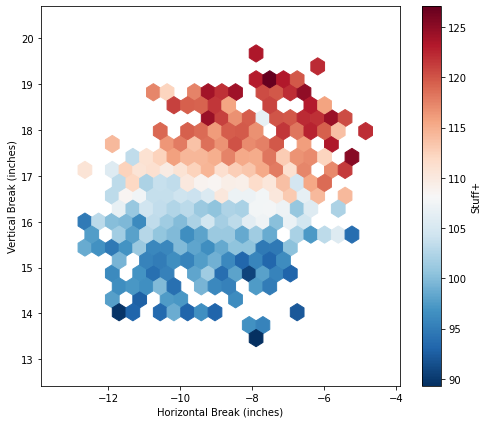

In [22]:
df_p = df_scored[df_scored['PlayerName'] == 'Jacob deGrom']
df_p = df_p[df_p.pitch_type == 'FF']

stuff_movement_heatmap(df_p, stuff_col="Stuff+_global")

In [23]:
pitcher_history = (
    df_scored
    .groupby(["game_year", "PlayerName", "pitch_type"], as_index=False)
    .agg(
        Pitches=("pitch_type", "size"),
        StuffPlus=("Stuff+_pt", "mean"),
        Velo=("release_speed", "mean"),
        HB=("HB_obs", "mean"),
        iVB=("pfx_z", "mean"),
        Spin=("release_spin_rate", "mean"),
        SpinAxis=("spin_axis", "mean"),
        SpinEff=("spin_efficiency", "mean"),
        SSW=("ssw_in", "mean"),
        ArmAngle=("arm_angle", "mean"),
        Extension=("release_extension", "mean"),
    )
)

# Add IP — one value per pitcher-season, broadcast across all pitch type rows
ip_per_pitcher = (
    df_scored[["PlayerName", "game_year", "IP"]]
    .dropna(subset=["IP"])
    .groupby(["PlayerName", "game_year"])["IP"]
    .max()
    .reset_index()
)

pitcher_history = pitcher_history.merge(
    ip_per_pitcher, on=["PlayerName", "game_year"], how="left"
)

min_year = min(rolling_results["results_by_year"].keys())
pitcher_history = pitcher_history[pitcher_history['game_year'] >= min_year].copy()
pitcher_history.to_parquet("pitcher_history.parquet", index=False)

In [24]:
# -----------------------------
# Define export columns
# -----------------------------

EXPORT_COLS = [
    "pitcher",
    "PlayerName",
    "IP",
    "game_year",
    "game_date",
    "pitch_type",
    "pitch_name",

    "p_throws",
    "batter_handedness",
    "is_lefty",

    "release_speed",
    "release_spin_rate",
    "spin_axis",
    "spin_axis_x",
    "spin_axis_y",
    "spin_efficiency",

    "pfx_x",
    "pfx_z",
    "HB_obs",
    "iVB_obs",

    "HB_magnus_est",
    "iVB_magnus_est",

    "ssw_x",
    "ssw_z",
    "ssw_in",

    "release_pos_x",
    "release_pos_z",
    "release_extension",
    "flight_distance",
    "arm_angle",

    "primary_delta_release_speed",
    "primary_delta_pfx_x",
    "primary_delta_pfx_z",

    "pred_target_oos",
    "Stuff+_global",
    "Stuff+_pt",

    "is_arsenal",
]

# -----------------------------
# Shrink dataframe for export
# -----------------------------

EXPORT_COLS_PRESENT = [c for c in EXPORT_COLS if c in df_scored.columns]

df_export = df_scored[EXPORT_COLS_PRESENT].copy()

In [25]:
api = HfApi()
repo_id = "perld/stuff-plus-data"

if RETRAIN:
    # Upload all years' scored parquets and the new model
    for year, df_year in df_export.groupby("game_year"):
        filename = f"df_scored_{int(year)}.parquet"
        df_year.to_parquet(filename, index=False)
        api.upload_file(
            path_or_fileobj=filename,
            path_in_repo=filename,
            repo_id=repo_id,
            repo_type="dataset",
        )
else:
    # Only report_year data has changed
    _report_file = f"df_scored_{report_year}.parquet"
    df_export[df_export["game_year"] == report_year].to_parquet(
        _report_file, index=False
    )
    api.upload_file(
        path_or_fileobj=_report_file,
        path_in_repo=_report_file,
        repo_id=repo_id,
        repo_type="dataset",
    )

# Always upload pitcher_history and statcast cache
api.upload_file(
    path_or_fileobj="pitcher_history.parquet",
    path_in_repo="pitcher_history.parquet",
    repo_id=repo_id,
    repo_type="dataset",
)
api.upload_file(
    path_or_fileobj=CACHE_PATH,
    path_in_repo="statcast_raw_cache.parquet",
    repo_id=repo_id,
    repo_type="dataset",
)


df_scored_2024.parquet:   0%|          | 0.00/68.0M [00:00<?, ?B/s]

df_scored_2025.parquet:   0%|          | 0.00/68.4M [00:00<?, ?B/s]

df_scored_2026.parquet:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

pitcher_history.parquet:   0%|          | 0.00/740k [00:00<?, ?B/s]

statcast_raw_cache.parquet:   0%|          | 0.00/547M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/perld/stuff-plus-data/commit/8b33b0a4f63c3d9864a27a2d9a7dd7878a898544', commit_message='Upload statcast_raw_cache.parquet with huggingface_hub', commit_description='', oid='8b33b0a4f63c3d9864a27a2d9a7dd7878a898544', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/perld/stuff-plus-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='perld/stuff-plus-data'), pr_revision=None, pr_num=None)

In [26]:
player_pitch = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher", pitch_type_col])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

pitcher_overall = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher"])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

In [27]:
# Wide tables: one row per pitcher, pitch types as columns
wide_pt = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_pt")
wide_global = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_global")

# Combine into one table with suffixes
wide = (
    wide_pt.add_suffix("_pt")
    .join(wide_global.add_suffix("_global"), how="outer")
    .reset_index()
)

# Add pitcher-level overall Stuff+
wide = wide.merge(pitcher_overall, on="pitcher", how="left")

# Rename for readability
wide = wide.rename(columns={
    "StuffPlus_pt": "Stuff+_pt_overall",
    "StuffPlus_global": "Stuff+_global_overall",
})

pitcher_to_name = (
    df_scored[["pitcher", "PlayerName"]]
    .dropna(subset=["pitcher", "PlayerName"])
    .drop_duplicates(subset=["pitcher"])
    .set_index("pitcher")["PlayerName"]
)

wide["PlayerName"] = wide["pitcher"].map(pitcher_to_name)
cols = ["PlayerName", "pitcher"] + [c for c in wide.columns if c not in ["PlayerName", "pitcher"]]
wide = wide[cols]

# Merge IP into wide for the qualified leaderboard (report year only)
ip_report = ip_all[ip_all["game_year"] == report_year][["xMLBAMID", "IP"]].copy()
wide = wide.merge(
    ip_report,
    left_on="pitcher",
    right_on="xMLBAMID",
    how="left"
).drop(columns=["xMLBAMID"])

In [28]:
qualified = wide[wide["IP"] >= 162].sort_values("Stuff+_global_overall", ascending=False)
qualified

,PlayerName,pitcher,FF_pt,FS_pt,SI_pt,SL_pt,FF_global,FS_global,SI_global,SL_global,n_pitches,Stuff+_pt_overall,Stuff+_global_overall,IP


In [29]:
# pitch counts + usage (by pitcher-season)
counts = (
    df_scored.groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .size()
    .rename("n_pitches")
    .reset_index()
)

totals = (
    df_scored.groupby(["pitcher", 'game_year'])
    .size()
    .rename("n_total")
    .reset_index()
)

counts = counts.merge(totals, on=["pitcher", 'game_year'], how="left")
counts["usage"] = counts["n_pitches"] / counts["n_total"]

# pitch-level Stuff+ (restricted to arsenal pitches)
pitch_stuff = (
    df_scored[df_scored["is_arsenal"]]
    .groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .agg(
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

# Join usage onto pitch-level stuff
arsenal_profile = (
    pitch_stuff.merge(counts, on=["pitcher", "PlayerName", 'game_year', 'pitch_type'], how="left")
    .sort_values(["PlayerName", 'game_year', "usage"], ascending=[True, True, False])
)

arsenal_profile.head()

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
16,671096,Andrew Abbott,2026,FF,94.682483,92.618392,90,171,0.526316
0,519242,Chris Sale,2026,FF,98.852311,97.485574,73,161,0.453416
1,519242,Chris Sale,2026,SL,100.537319,102.026175,66,161,0.409938
8,650911,Cristopher Sánchez,2026,SI,104.056479,106.500654,89,183,0.486339
7,642547,Freddy Peralta,2026,FF,107.122209,107.138515,78,170,0.458824


In [30]:
# Pitcher-season arsenal
tmp = arsenal_profile.copy()
tmp["w_pt"]     = tmp["usage"] * tmp["StuffPlus_pt"]
tmp["w_global"] = tmp["usage"] * tmp["StuffPlus_global"]

arsenal_summary = (
    tmp.groupby(["pitcher", "PlayerName", "game_year"])
    .agg(
        n_total=("n_total", "max"),
        n_arsenal_pitches=("pitch_type", "nunique"),

        StuffPlus_pt_overall=(
            "w_pt",
            lambda x: x.sum() / tmp.loc[x.index, "usage"].sum()
        ),
        StuffPlus_global_overall=(
            "w_global",
            lambda x: x.sum() / tmp.loc[x.index, "usage"].sum()
        ),
        top_pitch=(
            "StuffPlus_pt",
            lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]
        ),
        top_pitch_stuff=("StuffPlus_pt", "max"),
        primary_pitch=(
            "usage",
            lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]
        ),
        primary_pitch_usage=("usage", "max"),
    )
    .reset_index()
    .sort_values(["game_year", "StuffPlus_global_overall"], ascending=[False, False])
)

arsenal_summary.head()

,pitcher,PlayerName,game_year,n_total,n_arsenal_pitches,StuffPlus_pt_overall,StuffPlus_global_overall,top_pitch,top_pitch_stuff,primary_pitch,primary_pitch_usage
16,694819,Jacob Misiorowski,2026,178,1,109.459119,109.866246,FF,109.459119,FF,0.657303
5,642547,Freddy Peralta,2026,170,1,107.122209,107.138515,FF,107.122209,FF,0.458824
6,650911,Cristopher Sánchez,2026,183,1,104.056479,106.500654,SI,104.056479,SI,0.486339
4,601713,Nick Pivetta,2026,149,1,106.151325,106.005262,FF,106.151325,FF,0.590604
3,592332,Kevin Gausman,2026,172,2,103.555516,104.188425,FS,105.227935,FS,0.465116


In [31]:
if RETRAIN:
    # Feature importances by year
    importance_rows = []

    for yr, result in rolling_results["results_by_year"].items():
        importances = result["final_model"].feature_importances_
        for feature, importance in zip(model_features, importances):
            importance_rows.append({
                "year": yr,
                "feature": feature,
                "importance": importance,
            })

    importance_df = pd.DataFrame(importance_rows)

    importance_wide = importance_df.pivot(
        index="feature",
        columns="year",
        values="importance"
    )

    # Add average across years
    importance_wide["avg"] = importance_wide.mean(axis=1)

    # Sort by average importance descending
    importance_wide = importance_wide.sort_values("avg", ascending=False)

    importance_wide.astype(int)
else:
    print("Skipping feature importances in score-only mode.")
